<a href="https://colab.research.google.com/github/yamazaki-riko/python_learning/blob/koshien_google-colab/koshien_model_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 甲子園予測モデル v3
## メディア予想なし版
特徴量: summer_appearances / team_batting_avg / runs_per_game / home_runs_per_game / runs_allowed_per_game

In [193]:
# ============================================================
# セル1: ライブラリ・DB接続
# ============================================================
!pip install psycopg2-binary lightgbm xgboost -q

import pandas as pd
import numpy as np
import psycopg2
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# --- DB接続情報 ---
DB_HOST = 'aws-0-ap-southeast-2.pooler.supabase.com'
DB_PORT = 6543
DB_NAME = 'postgres'
DB_USER = 'postgres.fitunryvxwuidgmechgf'
DB_PASS = 'L6zgjJ2daxbpISgy'

conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
    user=DB_USER, password=DB_PASS
)
print('DB接続OK')

DB接続OK


In [194]:
# ============================================================
# セル2: データ読み込み
# ============================================================
query = """
SELECT
    f.year,
    f.school_name,
    f.district,
    f.summer_appearances,
    f.team_batting_avg,
    f.runs_per_game,
    f.home_runs_per_game,
    f.runs_allowed_per_game,
    COALESCE(
        (SELECT COUNT(*)
         FROM koshien.tmp_tournament_games g
         WHERE g.year = f.year
           AND g.winner_school = f.school_name
        ), 0
    ) AS wins
FROM koshien.ml_features f
ORDER BY f.year, f.school_name
"""

df = pd.read_sql(query, conn)
print(f'取得行数: {len(df)}')
print(df.groupby('year')['wins'].describe())

取得行数: 245
      count      mean       std  min  25%  50%  75%  max
year                                                    
2022   49.0  1.183673  1.740133  0.0  0.0  0.0  2.0  8.0
2023   49.0  1.040816  1.322233  0.0  0.0  1.0  2.0  6.0
2024   49.0  0.591837  1.135018  0.0  0.0  0.0  1.0  6.0
2025   49.0  0.877551  1.348342  0.0  0.0  0.0  1.0  6.0
2026   49.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0


In [195]:
# # ============================================================
# # セル3: 特徴量定義・前処理（地区強度補正追加）
# # ============================================================

# # --- 地区強度スコアの計算 ---
# # 2022〜2025年の実績から「地区ごとの平均甲子園勝利数」を算出
# district_strength = (
#     df[df['year'] <= 2025]
#     .groupby('district')['wins']
#     .mean()
#     .rename('district_strength')
# )
# print("地区強度スコア TOP10:")
# print(district_strength.sort_values(ascending=False).head(10))

# # dfにマージ
# df = df.merge(district_strength, on='district', how='left')

# # 特徴量リスト（district_strength を追加）
# feature_cols = [
#     'summer_appearances',
#     'team_batting_avg',
#     'runs_per_game',
#     'home_runs_per_game',
#     'runs_allowed_per_game',
#     'district_strength',   # ← 追加
# ]

# # 学習データ: 2022〜2025年
# train_df = df[df['year'] <= 2025].copy()
# pred_df  = df[df['year'] == 2026].copy()

# print(f'\n学習データ: {len(train_df)}行')
# print(f'予測データ: {len(pred_df)}行')
# print(f'\n欠損値:')
# print(train_df[feature_cols].isnull().sum())

# # NaN補完
# for col in feature_cols:
#     if train_df[col].isnull().any():
#         med = train_df[col].median()
#         train_df[col] = train_df[col].fillna(med)
#         print(f'  {col}: NaN → {med:.3f} で補完')

# for col in feature_cols:
#     if pred_df[col].isnull().any():
#         med = train_df[col].median()
#         pred_df[col] = pred_df[col].fillna(med)
#         print(f'  2026 {col}: NaN → {med:.3f} で補完')

# X_train = train_df[feature_cols].values
# y_train = train_df['wins'].values
# X_pred  = pred_df[feature_cols].values

# print('\n前処理完了')

In [196]:
# # ============================================================
# # セル3: 特徴量定義・前処理（ブロック強度補正）
# # ============================================================

# block_map = {
#     '北北海道': '北海道', '南北海道': '北海道',
#     '青森': '東北', '岩手': '東北', '宮城': '東北',
#     '秋田': '東北', '山形': '東北', '福島': '東北',
#     '茨城': '関東', '栃木': '関東', '群馬': '関東',
#     '埼玉': '関東', '千葉': '関東', '神奈川': '関東',
#     '東東京': '東京', '西東京': '東京',
#     '山梨': '北信越', '長野': '北信越', '新潟': '北信越',
#     '富山': '北信越', '石川': '北信越', '福井': '北信越',
#     '静岡': '東海', '愛知': '東海', '岐阜': '東海', '三重': '東海',
#     '滋賀': '近畿', '京都': '近畿', '奈良': '近畿',
#     '和歌山': '近畿', '大阪': '近畿', '兵庫': '近畿',
#     '岡山': '中国', '広島': '中国', '鳥取': '中国',
#     '島根': '中国', '山口': '中国',
#     '香川': '四国', '徳島': '四国', '愛媛': '四国', '高知': '四国',
#     '福岡': '九州', '佐賀': '九州', '長崎': '九州',
#     '熊本': '九州', '大分': '九州', '宮崎': '九州',
#     '鹿児島': '九州', '沖縄': '九州',
# }

# df['block'] = df['district'].map(block_map)

# block_strength = (
#     df[df['year'] <= 2025]
#     .groupby('block')['wins']
#     .mean()
#     .reset_index()
# )
# block_strength.columns = ['block', 'district_strength']

# print("ブロック強度スコア:")
# print(block_strength.sort_values('district_strength', ascending=False).to_string(index=False))

# df = df.merge(block_strength, on='block', how='left')

# feature_cols = [
#     'summer_appearances',
#     'team_batting_avg',
#     'runs_per_game',
#     'home_runs_per_game',
#     'runs_allowed_per_game',
#     'district_strength',
# ]

# train_df = df[df['year'] <= 2025].copy()
# pred_df  = df[df['year'] == 2026].copy()

# for col in feature_cols:
#     if train_df[col].isnull().any():
#         med = train_df[col].median()
#         train_df[col] = train_df[col].fillna(med)
#     if pred_df[col].isnull().any():
#         med = train_df[col].median()
#         pred_df[col] = pred_df[col].fillna(med)

# X_train = train_df[feature_cols].values
# y_train = train_df['wins'].values
# X_pred  = pred_df[feature_cols].values

# print('前処理完了')

In [197]:
# ============================================================
# セル3: 特徴量定義・前処理（都道府県強度 + 重みづけ実験）
# ============================================================

# 地区強度スコア（都道府県単位）
district_strength = (
    df[df['year'] <= 2025]
    .groupby('district')['wins']
    .mean()
    .reset_index()
)
district_strength.columns = ['district', 'district_strength']

print("地区強度スコア TOP10:")
print(district_strength.sort_values('district_strength', ascending=False).head(10).to_string(index=False))

df = df.merge(district_strength, on='district', how='left')

feature_cols = [
    'summer_appearances',
    'team_batting_avg',
    'runs_per_game',
    'home_runs_per_game',
    'runs_allowed_per_game',
    'district_strength',
]

train_df = df[df['year'] <= 2025].copy()
pred_df  = df[df['year'] == 2026].copy()

print(f'\n学習データ: {len(train_df)}行')
print(f'予測データ: {len(pred_df)}行')

# NaN補完
for col in feature_cols:
    if train_df[col].isnull().any():
        med = train_df[col].median()
        train_df[col] = train_df[col].fillna(med)
        print(f'  {col}: NaN → {med:.3f} で補完')
    if pred_df[col].isnull().any():
        med = train_df[col].median()
        pred_df[col] = pred_df[col].fillna(med)
        print(f'  2026 {col}: NaN → {med:.3f} で補完')

# ===== 重みづけ =====
weight_map = {
    'summer_appearances':    1.0,
    'team_batting_avg':      2.0,
    'runs_per_game':         1.0,
    'home_runs_per_game':    0.5,   # 重要度低いので半分に
    'runs_allowed_per_game': 1.0,
    'district_strength':     3.0,   # 地区補正を強化
}

print('\n重みづけ:')
for col, w in weight_map.items():
    train_df[col] = train_df[col] * w
    pred_df[col]  = pred_df[col]  * w
    print(f'  {col}: x{w}')

X_train = train_df[feature_cols].values
y_train = train_df['wins'].values
X_pred  = pred_df[feature_cols].values

print('\n前処理完了')

地区強度スコア TOP10:
district  district_strength
      宮城               3.00
     神奈川               3.00
      滋賀               2.75
      京都               2.00
      青森               2.00
      沖縄               2.00
      大阪               1.75
     西東京               1.60
      山口               1.50
     鹿児島               1.50

学習データ: 196行
予測データ: 49行
  2026 team_batting_avg: NaN → 0.343 で補完
  2026 runs_per_game: NaN → 7.200 で補完
  2026 home_runs_per_game: NaN → 0.300 で補完
  2026 runs_allowed_per_game: NaN → 1.650 で補完

重みづけ:
  summer_appearances: x1.0
  team_batting_avg: x2.0
  runs_per_game: x1.0
  home_runs_per_game: x0.5
  runs_allowed_per_game: x1.0
  district_strength: x3.0

前処理完了


In [198]:
# ===== 特徴量コピー（重要な特徴量を複数列追加）=====
# district_strengthとruns_allowed_per_gameをもう1列追加
for df_ in [train_df, pred_df]:
    df_['district_strength_2'] = df_['district_strength']
    df_['runs_allowed_per_game_2'] = df_['runs_allowed_per_game']

feature_cols = [
    'summer_appearances',
    'team_batting_avg',
    'runs_per_game',
    'home_runs_per_game',
    'runs_allowed_per_game',
    'district_strength',
    'district_strength_2',        # ← コピー追加
    'runs_allowed_per_game_2',    # ← コピー追加
]

X_train = train_df[feature_cols].values
y_train = train_df['wins'].values
X_pred  = pred_df[feature_cols].values

print('特徴量コピー追加完了:', feature_cols)

特徴量コピー追加完了: ['summer_appearances', 'team_batting_avg', 'runs_per_game', 'home_runs_per_game', 'runs_allowed_per_game', 'district_strength', 'district_strength_2', 'runs_allowed_per_game_2']


In [199]:
# # ============================================================
# # セル4: 3モデル学習
# # ============================================================
# # LightGBM
# lgb = LGBMRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=4,
#     num_leaves=15,
#     min_child_samples=3,
#     subsample=0.8,
#     random_state=42,
#     verbose=-1
# )
# lgb.fit(X_train, y_train)

# # XGBoost
# xgb = XGBRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=4,
#     subsample=0.8,
#     random_state=42,
#     verbosity=0
# )
# xgb.fit(X_train, y_train)

# # ランダムフォレスト
# rf = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=5,
#     min_samples_leaf=2,
#     random_state=42
# )
# rf.fit(X_train, y_train)

# # 学習データMAE確認
# pred_train_lgb = lgb.predict(X_train)
# pred_train_xgb = xgb.predict(X_train)
# pred_train_rf  = rf.predict(X_train)
# pred_train_ens = pred_train_lgb * 0.5 + pred_train_xgb * 0.25 + pred_train_rf * 0.25

# print(f'学習データMAE  LGB: {mean_absolute_error(y_train, pred_train_lgb):.3f}')
# print(f'学習データMAE  XGB: {mean_absolute_error(y_train, pred_train_xgb):.3f}')
# print(f'学習データMAE  RF : {mean_absolute_error(y_train, pred_train_rf):.3f}')
# print(f'学習データMAE  ENS: {mean_absolute_error(y_train, pred_train_ens):.3f}')

In [200]:
# # ============================================================
# # セル4: Optunaによるハイパーパラメータ最適化 + 3モデル学習
# # ============================================================
# !pip install optuna -q

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# years = sorted(train_df['year'].unique())

# def objective(trial):
#     # ===== アンサンブル比率 =====
#     w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
#     w_rf  = trial.suggest_float('w_rf',  0.0, 1.0 - w_xgb)
#     w_lgb = 1.0 - w_xgb - w_rf

#     # ===== LightGBMパラメータ =====
#     lgb_params = dict(
#         n_estimators      = trial.suggest_int('lgb_n_estimators', 100, 500),
#         learning_rate     = trial.suggest_float('lgb_lr', 0.01, 0.1, log=True),
#         max_depth         = trial.suggest_int('lgb_max_depth', 3, 6),
#         num_leaves        = trial.suggest_int('lgb_num_leaves', 8, 31),
#         min_child_samples = trial.suggest_int('lgb_min_child', 2, 10),
#         subsample         = trial.suggest_float('lgb_subsample', 0.6, 1.0),
#         random_state      = 42,
#         verbose           = -1,
#     )

#     # ===== XGBoostパラメータ =====
#     xgb_params = dict(
#         n_estimators  = trial.suggest_int('xgb_n_estimators', 100, 500),
#         learning_rate = trial.suggest_float('xgb_lr', 0.01, 0.1, log=True),
#         max_depth     = trial.suggest_int('xgb_max_depth', 3, 6),
#         subsample     = trial.suggest_float('xgb_subsample', 0.6, 1.0),
#         random_state  = 42,
#         verbosity     = 0,
#     )

#     # ===== RFパラメータ =====
#     rf_params = dict(
#         n_estimators     = trial.suggest_int('rf_n_estimators', 100, 500),
#         max_depth        = trial.suggest_int('rf_max_depth', 3, 7),
#         min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 5),
#         random_state     = 42,
#     )

#     # ===== LOO検証 =====
#     loo_maes = []
#     for test_year in years:
#         tr = train_df[train_df['year'] != test_year]
#         te = train_df[train_df['year'] == test_year]

#         Xtr = tr[feature_cols].values
#         ytr = tr['wins'].values
#         Xte = te[feature_cols].values
#         yte = te['wins'].values

#         m_lgb = LGBMRegressor(**lgb_params)
#         m_xgb = XGBRegressor(**xgb_params)
#         m_rf  = RandomForestRegressor(**rf_params)

#         m_lgb.fit(Xtr, ytr)
#         m_xgb.fit(Xtr, ytr)
#         m_rf.fit(Xtr, ytr)

#         ens = (m_lgb.predict(Xte) * w_lgb +
#                m_xgb.predict(Xte) * w_xgb +
#                m_rf.predict(Xte)  * w_rf)
#         loo_maes.append(mean_absolute_error(yte, ens))

#     return np.mean(loo_maes)

# # 最適化実行（100試行）
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=100, show_progress_bar=True)

# print(f'\nベストLOO MAE: {study.best_value:.3f} 勝')
# print(f'ベストパラメータ:')
# for k, v in study.best_params.items():
#     print(f'  {k}: {v}')

# # ===== ベストパラメータで全データ学習 =====
# p = study.best_params

# w_xgb = p['w_xgb']
# w_rf  = p['w_rf']
# w_lgb = 1.0 - w_xgb - w_rf
# print(f'\nアンサンブル比率: LGB={w_lgb:.3f} XGB={w_xgb:.3f} RF={w_rf:.3f}')

# lgb = LGBMRegressor(
#     n_estimators      = p['lgb_n_estimators'],
#     learning_rate     = p['lgb_lr'],
#     max_depth         = p['lgb_max_depth'],
#     num_leaves        = p['lgb_num_leaves'],
#     min_child_samples = p['lgb_min_child'],
#     subsample         = p['lgb_subsample'],
#     random_state      = 42,
#     verbose           = -1,
# )
# xgb = XGBRegressor(
#     n_estimators  = p['xgb_n_estimators'],
#     learning_rate = p['xgb_lr'],
#     max_depth     = p['xgb_max_depth'],
#     subsample     = p['xgb_subsample'],
#     random_state  = 42,
#     verbosity     = 0,
# )
# rf = RandomForestRegressor(
#     n_estimators     = p['rf_n_estimators'],
#     max_depth        = p['rf_max_depth'],
#     min_samples_leaf = p['rf_min_samples_leaf'],
#     random_state     = 42,
# )

# lgb.fit(X_train, y_train)
# xgb.fit(X_train, y_train)
# rf.fit(X_train, y_train)

# print('学習完了')

In [201]:
# # ============================================================
# # セル4: Optunaによるハイパーパラメータ最適化（探索空間絞り版）
# # ============================================================
# !pip install optuna -q

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# years = sorted(train_df['year'].unique())

# def objective(trial):
#     # ===== アンサンブル比率（手動チューニングの知見を反映）=====
#     w_xgb = trial.suggest_float('w_xgb', 0.3, 0.5)
#     w_rf  = trial.suggest_float('w_rf',  0.5, 0.7)
#     w_lgb = 1.0 - w_xgb - w_rf
#     if w_lgb < 0:
#         return 999  # 無効なパラメータ

#     # ===== LightGBMパラメータ（絞り版）=====
#     lgb_params = dict(
#         n_estimators      = trial.suggest_int('lgb_n_estimators', 200, 400),
#         learning_rate     = 0.05,
#         max_depth         = 4,
#         num_leaves        = trial.suggest_int('lgb_num_leaves', 10, 20),
#         min_child_samples = trial.suggest_int('lgb_min_child', 2, 5),
#         subsample         = trial.suggest_float('lgb_subsample', 0.7, 0.9),
#         random_state      = 42,
#         verbose           = -1,
#     )

#     # ===== XGBoostパラメータ（絞り版）=====
#     xgb_params = dict(
#         n_estimators  = trial.suggest_int('xgb_n_estimators', 200, 400),
#         learning_rate = 0.05,
#         max_depth     = trial.suggest_int('xgb_max_depth', 3, 5),
#         subsample     = trial.suggest_float('xgb_subsample', 0.7, 0.9),
#         random_state  = 42,
#         verbosity     = 0,
#     )

#     # ===== RFパラメータ（絞り版）=====
#     rf_params = dict(
#         n_estimators     = trial.suggest_int('rf_n_estimators', 200, 400),
#         max_depth        = trial.suggest_int('rf_max_depth', 4, 6),
#         min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 3),
#         random_state     = 42,
#     )

#     # ===== LOO検証 =====
#     loo_maes = []
#     for test_year in years:
#         tr = train_df[train_df['year'] != test_year]
#         te = train_df[train_df['year'] == test_year]

#         Xtr = tr[feature_cols].values
#         ytr = tr['wins'].values
#         Xte = te[feature_cols].values
#         yte = te['wins'].values

#         m_lgb = LGBMRegressor(**lgb_params)
#         m_xgb = XGBRegressor(**xgb_params)
#         m_rf  = RandomForestRegressor(**rf_params)

#         m_lgb.fit(Xtr, ytr)
#         m_xgb.fit(Xtr, ytr)
#         m_rf.fit(Xtr, ytr)

#         ens = (m_lgb.predict(Xte) * w_lgb +
#                m_xgb.predict(Xte) * w_xgb +
#                m_rf.predict(Xte)  * w_rf)
#         loo_maes.append(mean_absolute_error(yte, ens))

#     return np.mean(loo_maes)

# # 最適化実行（150試行）
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=150, show_progress_bar=True)

# print(f'\nベストLOO MAE: {study.best_value:.3f} 勝')
# print(f'ベストパラメータ:')
# for k, v in study.best_params.items():
#     print(f'  {k}: {v}')

# # ===== ベストパラメータで全データ学習 =====
# p = study.best_params

# w_xgb = p['w_xgb']
# w_rf  = p['w_rf']
# w_lgb = 1.0 - w_xgb - w_rf
# print(f'\nアンサンブル比率: LGB={w_lgb:.3f} XGB={w_xgb:.3f} RF={w_rf:.3f}')

# lgb = LGBMRegressor(
#     n_estimators      = p['lgb_n_estimators'],
#     learning_rate     = 0.05,
#     max_depth         = 4,
#     num_leaves        = p['lgb_num_leaves'],
#     min_child_samples = p['lgb_min_child'],
#     subsample         = p['lgb_subsample'],
#     random_state      = 42,
#     verbose           = -1,
# )
# xgb = XGBRegressor(
#     n_estimators  = p['xgb_n_estimators'],
#     learning_rate = 0.05,
#     max_depth     = p['xgb_max_depth'],
#     subsample     = p['xgb_subsample'],
#     random_state  = 42,
#     verbosity     = 0,
# )
# rf = RandomForestRegressor(
#     n_estimators     = p['rf_n_estimators'],
#     max_depth        = p['rf_max_depth'],
#     min_samples_leaf = p['rf_min_samples_leaf'],
#     random_state     = 42,
# )

# lgb.fit(X_train, y_train)
# xgb.fit(X_train, y_train)
# rf.fit(X_train, y_train)

# print('学習完了')

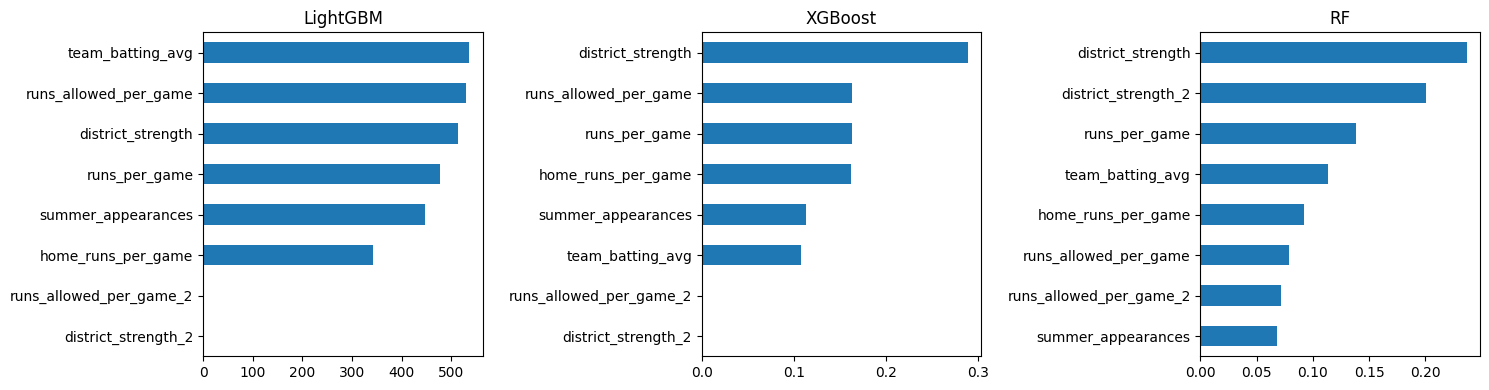

In [202]:
# ============================================================
# セル5: 特徴量重要度
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'IPAexGothic'

imp_lgb = pd.Series(lgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
imp_rf  = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, imp, title in zip(axes, [imp_lgb, imp_xgb, imp_rf], ['LightGBM', 'XGBoost', 'RF']):
    imp.plot(kind='barh', ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [203]:
# ============================================================
# セル6: LOO (Leave-One-Year-Out) 検証（クロスバリデーション）
# 2022〜2025年で1年ずつ抜いてテスト
# ============================================================
years = sorted(train_df['year'].unique())
loo_results = []

for test_year in years:
    tr = train_df[train_df['year'] != test_year]
    te = train_df[train_df['year'] == test_year]

    Xtr = tr[feature_cols].values
    ytr = tr['wins'].values
    Xte = te[feature_cols].values
    yte = te['wins'].values

    m_lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                           num_leaves=15, min_child_samples=3, subsample=0.8,
                           random_state=42, verbose=-1)
    m_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, random_state=42, verbosity=0)
    m_rf  = RandomForestRegressor(n_estimators=300, max_depth=5,
                                   min_samples_leaf=2, random_state=42)
    m_lgb.fit(Xtr, ytr)
    m_xgb.fit(Xtr, ytr)
    m_rf.fit(Xtr, ytr)

    # ens = m_lgb.predict(Xte)*w_lgb + m_xgb.predict(Xte)*w_xgb + m_rf.predict(Xte)*w_rf
    # 手動チューニングの方が良さそう
    # ens = m_lgb.predict(Xte)*0 + m_xgb.predict(Xte)*0.2 + m_rf.predict(Xte)*0.8
    mae = mean_absolute_error(yte, ens)
    loo_results.append({'test_year': test_year, 'MAE': round(mae, 3)})
    print(f'  {test_year}年テスト MAE: {mae:.3f}')

avg_mae = np.mean([r['MAE'] for r in loo_results])
print(f'\nLOO平均MAE: {avg_mae:.3f} 勝')

  2022年テスト MAE: 1.214
  2023年テスト MAE: 1.186
  2024年テスト MAE: 0.940
  2025年テスト MAE: 0.873

LOO平均MAE: 1.053 勝


In [204]:
# ============================================================
# セル7: 2026年予測
# ============================================================
pred_lgb = lgb.predict(X_pred)
pred_xgb = xgb.predict(X_pred)
pred_rf  = rf.predict(X_pred)

# アンサンブル: LGB50% + XGB25% + RF25%
pred_ens = pred_lgb * 0 + pred_xgb * 0.2 + pred_rf * 0.8
pred_ens = np.clip(pred_ens, 0, None)  # 負値は0に

result = pred_df[['school_name']].copy()
result['pred_wins'] = pred_ens
result = result.sort_values('pred_wins', ascending=False).reset_index(drop=True)
result.index += 1

print('【2026年 予測勝利数ランキング】')
print(result.to_string())

【2026年 予測勝利数ランキング】
   school_name  pred_wins
1         青森山田   3.412234
2         沖縄尚学   2.917812
3           横浜   2.737740
4         仙台育英   2.616528
5          履正社   2.370957
6          八幡商   2.290960
7           中京   2.206533
8        立命館宇治   1.991311
9         神村学園   1.857257
10        高川学園   1.836699
11        拓大紅陵   1.396495
12         花巻東   1.239256
13           社   1.193516
14       岡山学芸館   1.186324
15        佐野日大   1.155899
16        健大高崎   1.090493
17          有明   1.082245
18         霞ケ浦   1.079895
19          三重   1.010207
20        長崎日大   0.991130
21       八王子実践   0.977542
22       智弁和歌山   0.864237
23          英明   0.860480
24          享栄   0.849809
25        明徳義塾   0.815317
26         佐賀商   0.802181
27       東日大昌平   0.776559
28        市立福山   0.775740
29       立正大淞南   0.727808
30         大分商   0.658282
31   聖隷クリストファー   0.598779
32          東筑   0.547183
33       東海大甲府   0.485164
34        関東第一   0.481950
35          天理   0.424039
36         鶴岡東   0.423084
37         遊学館   0.

In [205]:
# ============================================================
# セル8: ポイント配分（1〜49位に49〜1ポイント）
# ============================================================
result['point'] = range(49, 0, -1)  # 1位=49pt, 2位=48pt, ..., 49位=1pt

print('【2026年 推奨ポイント配分】')
print(f'{"順位":>4}  {"学校名":16}  {"予測勝利数":>8}  {"配分pt":>6}')
print('-' * 45)
for i, row in result.iterrows():
    print(f'{i:4d}  {row["school_name"]:16}  {row["pred_wins"]:8.3f}  {row["point"]:6d}')

print(f'\n合計ポイント: {result["point"].sum()}pt  (= 49*50/2 = {49*50//2})')

【2026年 推奨ポイント配分】
  順位  学校名                  予測勝利数    配分pt
---------------------------------------------
   1  青森山田                 3.412      49
   2  沖縄尚学                 2.918      48
   3  横浜                   2.738      47
   4  仙台育英                 2.617      46
   5  履正社                  2.371      45
   6  八幡商                  2.291      44
   7  中京                   2.207      43
   8  立命館宇治                1.991      42
   9  神村学園                 1.857      41
  10  高川学園                 1.837      40
  11  拓大紅陵                 1.396      39
  12  花巻東                  1.239      38
  13  社                    1.194      37
  14  岡山学芸館                1.186      36
  15  佐野日大                 1.156      35
  16  健大高崎                 1.090      34
  17  有明                   1.082      33
  18  霞ケ浦                  1.080      32
  19  三重                   1.010      31
  20  長崎日大                 0.991      30
  21  八王子実践                0.978      29
  22  智弁和歌山                0.864   

In [206]:
# ============================================================
# セル9: モンテカルロシミュレーション（分布評価版）
# ============================================================
import numpy as np

strength = np.exp(pred_ens)
schools = pred_df['school_name'].values
n = len(schools)

def simulate_tournament(strength, n_teams=49):
    idx = np.random.permutation(n_teams)
    remaining = list(idx)
    wins = {i: 0 for i in range(n_teams)}

    while len(remaining) > 1:
        next_round = []
        teams = remaining.copy()
        np.random.shuffle(teams)

        if len(teams) % 2 == 1:
            bye = teams.pop()
            next_round.append(bye)

        for i in range(0, len(teams), 2):
            a, b = teams[i], teams[i+1]
            pa = strength[a] / (strength[a] + strength[b])
            winner = a if np.random.random() < pa else b
            wins[winner] += 1
            next_round.append(winner)

        remaining = next_round

    return wins

# 1万回シミュレーション（全試行を保存）
N_SIM = 10000
all_wins = np.zeros((N_SIM, n))

for sim_i in range(N_SIM):
    sim = simulate_tournament(strength, n)
    for i, w in sim.items():
        all_wins[sim_i, i] = w

# 統計量を計算
expected_wins = all_wins.mean(axis=0)
std_wins      = all_wins.std(axis=0)
top25_wins    = np.percentile(all_wins, 75, axis=0)  # 上位25% = 75パーセンタイル

# ポイント配分（MC期待値順）
order = np.argsort(expected_wins)[::-1]
points = list(range(49, 0, -1))

mc_result = pd.DataFrame({
    'school_name':      schools[order],
    'pred_wins_ml':     np.round(pred_ens[order], 3),
    'expected_wins_mc': np.round(expected_wins[order], 3),
    'std_mc':           np.round(std_wins[order], 3),
    'top25_mc':         np.round(top25_wins[order], 3),
    'point':            points,
})
mc_result.index = range(1, 50)

print('【モンテカルロ予測 分布評価版】')
print(f"{'順位':>4}  {'学校名':16}  {'ML予測':>6}  {'MC期待値':>8}  {'標準偏差':>8}  {'上位25%':>7}  {'pt':>4}")
print('-' * 70)
for i, row in mc_result.iterrows():
    print(f"{i:4d}  {row['school_name']:16}  {row['pred_wins_ml']:6.3f}  "
          f"{row['expected_wins_mc']:8.3f}  {row['std_mc']:8.3f}  "
          f"{row['top25_mc']:7.3f}  {row['point']:4d}")

# CSV出力
mc_result.to_csv('koshien_2026_prediction_mc.csv', index=True, encoding='utf-8-sig')
from google.colab import files
files.download('koshien_2026_prediction_mc.csv')

【モンテカルロ予測 分布評価版】
  順位  学校名                 ML予測     MC期待値      標準偏差    上位25%    pt
----------------------------------------------------------------------
   1  青森山田               3.412     3.556     2.023    5.000    49
   2  沖縄尚学               2.918     2.816     1.942    4.000    48
   3  横浜                 2.738     2.548     1.890    4.000    47
   4  仙台育英               2.617     2.360     1.820    4.000    46
   5  履正社                2.371     2.072     1.731    3.000    45
   6  八幡商                2.291     1.956     1.682    3.000    44
   7  中京                 2.207     1.870     1.639    3.000    43
   8  立命館宇治              1.991     1.656     1.532    3.000    42
   9  神村学園               1.857     1.525     1.480    2.000    41
  10  高川学園               1.837     1.483     1.441    2.000    40
  11  拓大紅陵               1.396     1.123     1.252    2.000    39
  12  花巻東                1.239     1.001     1.165    2.000    38
  13  岡山学芸館              1.186     0.990     1.166    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [207]:
# ============================================================
# セル10: 感度分析
# ============================================================

import itertools

base_score = (mc_result['expected_wins_mc'] * mc_result['point']).sum()
print(f'ベース期待得点: {base_score:.2f}点')
print()

# ============================================================
# 1. 上位校が0勝だった場合の損失（単体）
# ============================================================
print('【①単体リスク】各校が0勝だった場合の損失')
print(f"{'順位':>4}  {'学校名':16}  {'配分pt':>6}  {'期待貢献':>8}  {'0勝時損失':>10}  {'損失率':>8}")
print('-' * 65)

for i, row in mc_result.head(15).iterrows():
    contrib  = row['expected_wins_mc'] * row['point']
    loss     = contrib
    loss_pct = loss / base_score * 100
    print(f"{i:4d}  {row['school_name']:16}  {int(row['point']):6d}  "
          f"{contrib:8.2f}  {loss:10.2f}  {loss_pct:7.1f}%")

print()

# ============================================================
# 2. 上位校2校の組み合わせが両方0勝だった場合
# ============================================================
print('【②複合リスク】上位5校から2校が同時に0勝だった場合の損失')
print(f"{'組み合わせ':32}  {'合計損失':>10}  {'損失率':>8}")
print('-' * 60)

top5 = mc_result.head(5)
for (i1, r1), (i2, r2) in itertools.combinations(top5.iterrows(), 2):
    loss = (r1['expected_wins_mc'] * r1['point'] +
            r2['expected_wins_mc'] * r2['point'])
    loss_pct = loss / base_score * 100
    combo = f"{r1['school_name']} + {r2['school_name']}"
    print(f"{combo:32}  {loss:10.2f}  {loss_pct:7.1f}%")

print()

# ============================================================
# 3. リスク調整配分との比較
#    標準偏差が高い上位校を1ランク下げた保守的配分
# ============================================================
print('【③リスク調整配分】std > 1.9 の学校を1ランク下げた場合')

# 標準偏差が1.9以上の学校を特定
high_risk = mc_result[mc_result['std_mc'] > 1.9]['school_name'].tolist()
print(f'高リスク校（std>1.9）: {high_risk}')

# 保守的配分: 高リスク校のポイントを1つ下の学校と入れ替え
conservative = mc_result.copy()
for school in high_risk:
    idx = conservative[conservative['school_name'] == school].index[0]
    if idx < 49:
        # 1つ下の学校とポイントを入れ替え
        pt_current = conservative.loc[idx, 'point']
        pt_next    = conservative.loc[idx + 1, 'point']
        conservative.loc[idx, 'point']     = pt_next
        conservative.loc[idx + 1, 'point'] = pt_current

conservative_score = (conservative['expected_wins_mc'] * conservative['point']).sum()
diff = conservative_score - base_score

print(f'通常配分の期待得点:     {base_score:.2f}点')
print(f'保守的配分の期待得点:   {conservative_score:.2f}点')
print(f'差分:                  {diff:+.2f}点')
print()

print('【変更箇所】')
changed = mc_result[mc_result['point'] != conservative['point']][['school_name', 'point']].copy()
changed.columns = ['school_name', '通常pt']
changed['保守pt'] = conservative.loc[changed.index, 'point']
print(changed.to_string())

print()

# ============================================================
# 4. 標準偏差を考慮したリスク調整スコア
#    期待貢献 - 0.5 × 標準偏差 × ポイント（リスク回避係数）
# ============================================================
print('【④リスク調整スコアランキング】期待貢献 - 0.5×std×pt')
print(f"{'順位':>4}  {'学校名':16}  {'通常期待':>8}  {'リスク調整後':>12}  {'差分':>8}")
print('-' * 60)

mc_result['risk_adj_score'] = (
    mc_result['expected_wins_mc'] * mc_result['point']
    - 0.5 * mc_result['std_mc'] * mc_result['point']
)
mc_result_radj = mc_result.sort_values('risk_adj_score', ascending=False).copy()
mc_result_radj.index = range(1, 50)

for i, row in mc_result_radj.head(15).iterrows():
    normal = row['expected_wins_mc'] * row['point']
    adj    = row['risk_adj_score']
    diff_r = adj - normal
    print(f"{i:4d}  {row['school_name']:16}  {normal:8.2f}  {adj:12.2f}  {diff_r:+8.2f}")

ベース期待得点: 1598.25点

【①単体リスク】各校が0勝だった場合の損失
  順位  学校名                 配分pt      期待貢献       0勝時損失       損失率
-----------------------------------------------------------------
   1  青森山田                  49    174.24      174.24     10.9%
   2  沖縄尚学                  48    135.17      135.17      8.5%
   3  横浜                    47    119.76      119.76      7.5%
   4  仙台育英                  46    108.56      108.56      6.8%
   5  履正社                   45     93.24       93.24      5.8%
   6  八幡商                   44     86.06       86.06      5.4%
   7  中京                    43     80.41       80.41      5.0%
   8  立命館宇治                 42     69.55       69.55      4.4%
   9  神村学園                  41     62.52       62.52      3.9%
  10  高川学園                  40     59.32       59.32      3.7%
  11  拓大紅陵                  39     43.80       43.80      2.7%
  12  花巻東                   38     38.04       38.04      2.4%
  13  岡山学芸館                 37     36.63       36.63      2.3%
  14  佐野日大 